In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline



# Loading the dataset
insurance_data_path = 'insurance.csv'
insurance = pd.read_csv(insurance_data_path)
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [28]:
#Data preprocessing - Part 1
insurance.info()
insurance.describe()
print(insurance.isnull().sum())
print(insurance.dtypes)

#clean charges col 
insurance['charges']=insurance['charges'].replace({'\$': ''}, regex=True).astype(float)

insurance=insurance[insurance['age']>0]
insurance.loc[insurance['children']<0,'children']=0
print(insurance.dtypes)

#replace numeric missing data with average 
insurance=insurance.fillna(insurance.mean(numeric_only=True))
print(insurance.isnull().sum())

insurance['sex']=insurance['sex'].replace({'M':'male','man':'male','F':'female','woman':'female'})

insurance['region']=insurance['region'].str.lower()

#fill missing values in non-numeric cols with most frequent
for col in insurance.select_dtypes(include='object'):
    insurance[col].fillna(insurance[col].mode()[0], inplace=True)

print(insurance.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1272 non-null   float64
 1   sex       1272 non-null   object 
 2   bmi       1272 non-null   float64
 3   children  1272 non-null   float64
 4   smoker    1272 non-null   object 
 5   region    1272 non-null   object 
 6   charges   1284 non-null   object 
dtypes: float64(3), object(4)
memory usage: 73.3+ KB
age         66
sex         66
bmi         66
children    66
smoker      66
region      66
charges     54
dtype: int64
age         float64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges      object
dtype: object
age         float64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges     float64
dtype: object
age          0
sex         30
bmi          0
children     0
smok

In [29]:
#preprocessing - Part 2 - select features, scale and normalize 

insurance_n=pd.get_dummies(insurance,drop_first=True)
print(insurance_n.head())

y=insurance_n["charges"].values
X = insurance_n.drop("charges", axis=1).values

scaler = StandardScaler()

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

X_train_rescaled= scaler.fit_transform(X_train)
X_test_rescaled=scaler.transform(X_test)

model=LinearRegression()
model.fit(X_train_rescaled,y_train)

y_pred=model.predict(X_test_rescaled)
y_pred = np.maximum(y_pred, 1000)
y_pred_train=model.predict(X_train_rescaled)
y_pred = np.maximum(y_pred, 1000)


#model parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

#mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

#print("Mean squared error (test set):", mse_test)
print("R^2 (test set):", r2_test)


#mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

#mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

#print("Mean squared error (train set):", mse_train)
print("R^2 (train set):", r2_train)



    age     bmi  children  ...  region_northwest  region_southeast  region_southwest
0  19.0  27.900       0.0  ...                 0                 0                 1
1  18.0  33.770       1.0  ...                 0                 1                 0
2  28.0  33.000       3.0  ...                 0                 1                 0
3  33.0  22.705       0.0  ...                 1                 0                 0
4  32.0  28.880       0.0  ...                 1                 0                 0

[5 rows x 9 columns]
Intercept: 13346.397985660355
Coefficients: [3785.17295024 1879.59661209  360.34127028 -113.10113127 9539.96233809
  -57.77997535   69.73112441 -116.50481882]
R^2 (test set): 0.6259936850458533
R^2 (train set): 0.7457012840245987


In [30]:
#Using pipeline and choosing a model 

models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=0.1))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1))
    ])
}

print("Cross-validation results (negative MSE):\n")

best_model = None
best_score = -np.inf

for name, pipeline in models.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )
    
    mean_score = scores.mean()
    print(f"{name}: {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_model = pipeline

#Train best model on full training set
best_model.fit(X_train, y_train)

y_pred_n = best_model.predict(X_test)
y_pred = np.maximum(y_pred, 1000)
y_pred_n_train = best_model.predict(X_train)
y_pred_train = np.maximum(y_pred_n_train, 1000)

regressor = best_model.named_steps["model"]

# Print intercept
print("\nIntercept:", regressor.intercept_)

# Print coefficients (slopes)
print("Coefficients:", regressor.coef_)

mse = mean_squared_error(y_test, y_pred_n)
r2 = r2_score(y_test, y_pred_n)
r2_score=r2_score(y_train,y_pred_n_train)

print("\nBest model:", best_model)
print("Test MSE:", mse)
print("Test R^2:", r2)
print("Train R^2:",r2_score)



Cross-validation results (negative MSE):

Linear: 0.7370
Ridge: 0.7370
Lasso: 0.7370

Intercept: 13346.397985660355
Coefficients: [3785.08690559 1879.5215594   360.23985491 -112.98701358 9539.8547425
  -57.63724781   69.75482487 -116.34905379]

Best model: Pipeline(steps=[('scaler', StandardScaler()), ('model', Lasso(alpha=0.1))])
Test MSE: 50182116.688153446
Test R^2: 0.6251713000024562
Train R^2: 0.7457012835024455


In [31]:
validation_data=pd.read_csv("validation_dataset.csv")
validation_data.head()

validation_data=pd.get_dummies(validation_data, drop_first=True)
validation_data.head()
validation_data.info()

predict_validation=best_model.predict(validation_data)
predict_validation=np.maximum(predict_validation,1000)
validation_data["predicted_charges"]=predict_validation
validation_data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               50 non-null     float64
 1   bmi               50 non-null     float64
 2   children          50 non-null     float64
 3   sex_male          50 non-null     uint8  
 4   smoker_yes        50 non-null     uint8  
 5   region_northwest  50 non-null     uint8  
 6   region_southeast  50 non-null     uint8  
 7   region_southwest  50 non-null     uint8  
dtypes: float64(3), uint8(5)
memory usage: 1.5 KB


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,predicted_charges
0,18.0,24.090000,1.0,0,0,0,1,0,1135.547491
1,39.0,26.410000,0.0,1,1,0,0,0,30337.987887
2,27.0,29.150000,0.0,1,1,0,1,0,28143.103127
3,71.0,65.502135,13.0,1,1,0,1,0,55022.307997
4,28.0,38.060000,0.0,1,0,0,1,0,7581.382583


In [32]:
insurance_n["charges"].head()
print(insurance_n["charges"].nlargest(5))

543     63770.42801
1300    62592.87309
1230    60021.39897
577     58571.07448
819     55135.40209
Name: charges, dtype: float64


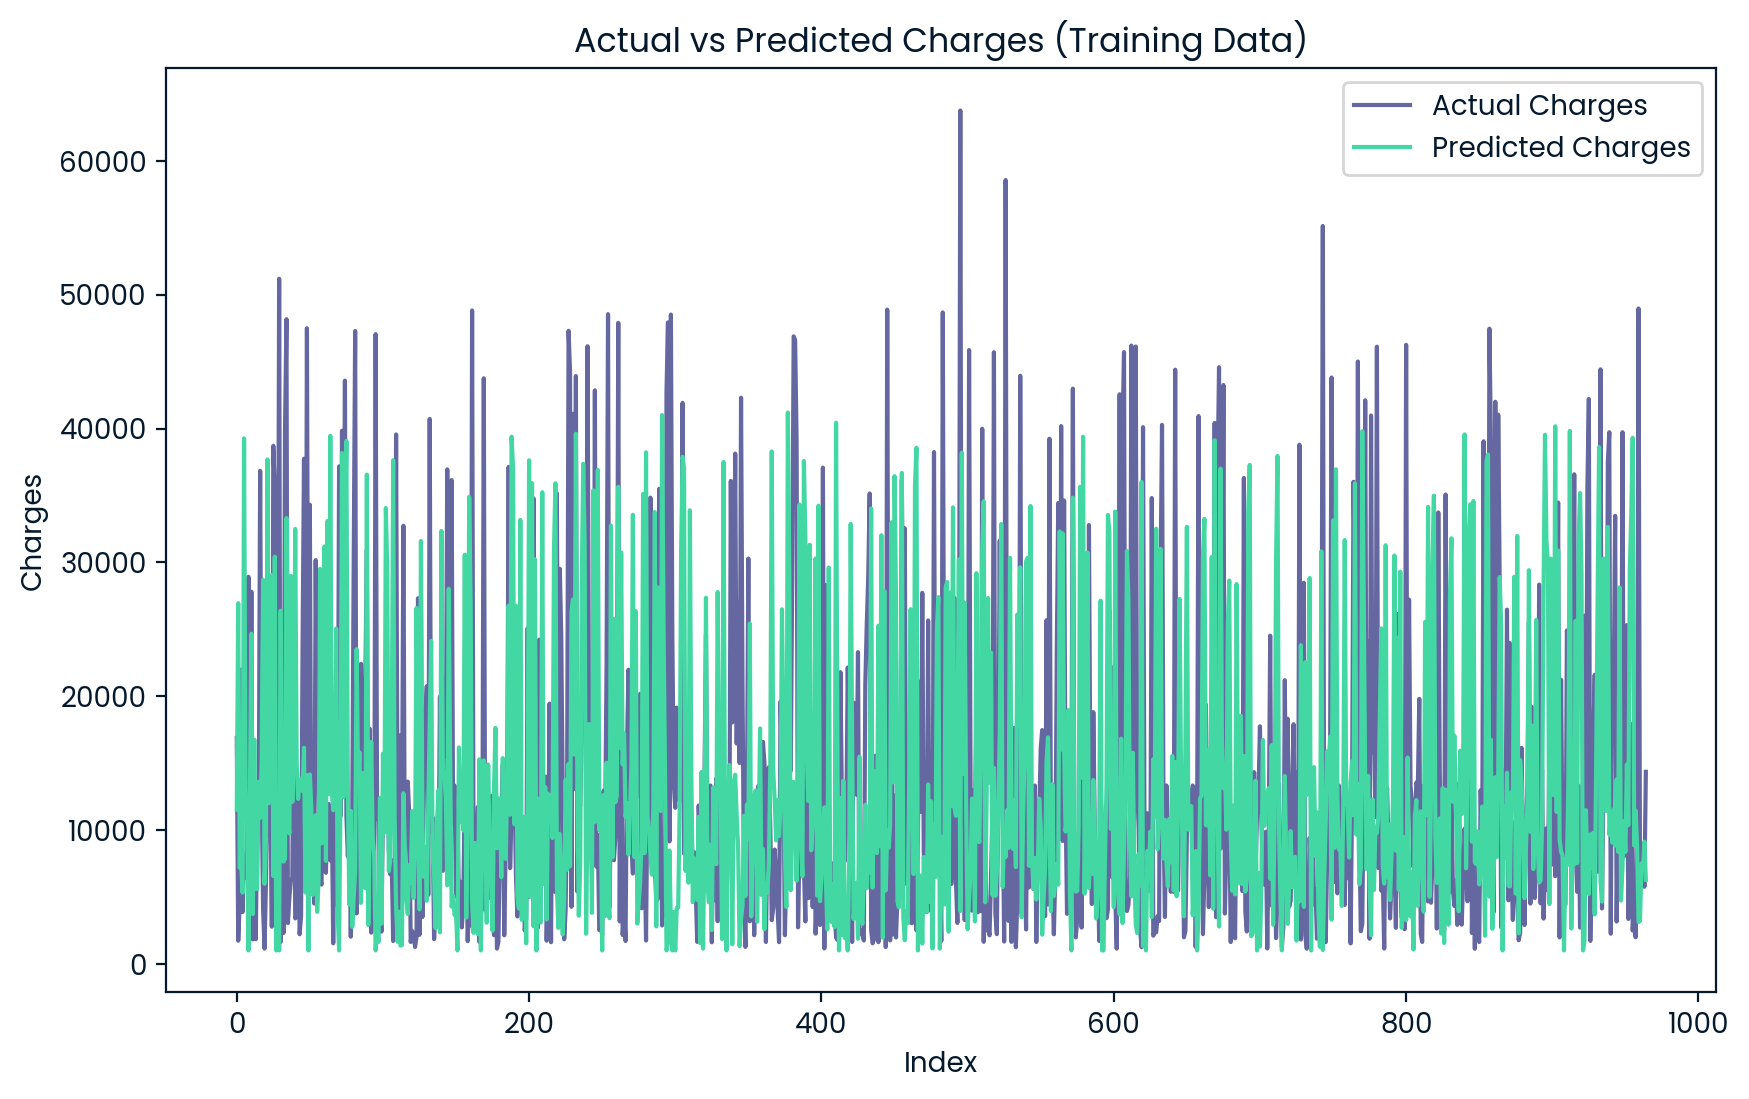

In [33]:
x = range(len(y_pred_train))


plt.figure(figsize=(10,6))

plt.plot(x, insurance_n["charges"].iloc[:len(y_pred_train)], label="Actual Charges")
plt.plot(x, y_pred_train, label="Predicted Charges")

plt.xlabel("Index")
plt.ylabel("Charges")
plt.title("Actual vs Predicted Charges (Training Data)")
plt.legend()

plt.show()